In [ ]:
!pip -q install xgboost joblib seaborn

In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
uploaded = files.upload()

CSV_FILE = next(iter(uploaded.keys()))

print("Uploaded file:", CSV_FILE)

Saving water_potability.csv to water_potability (1).csv
Uploaded file: water_potability (1).csv


In [ ]:
df = pd.read_csv(CSV_FILE)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
print("===== DATASET INFO =====")
df.info()

print("\n===== STATISTICAL SUMMARY =====")
display(df.describe())

print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())

print("\n===== DUPLICATE ROWS =====")
print(df.duplicated().sum())

print("\n===== MISSING VALUES =====")
display(df.isnull().sum())

print("\n===== TARGET DISTRIBUTION =====")
display(df["Potability"].value_counts())

print("\n===== TARGET PERCENTAGE =====")
display(df["Potability"].value_counts(normalize=True) * 100)

===== DATASET INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB

===== STATISTICAL SUMMARY =====


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000



===== COLUMN NAMES =====
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']

===== DUPLICATE ROWS =====
0

===== MISSING VALUES =====


,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0



===== TARGET DISTRIBUTION =====


,count
Potability,
0,1998
1,1278



===== TARGET PERCENTAGE =====


,proportion
Potability,
0,60.989011
1,39.010989


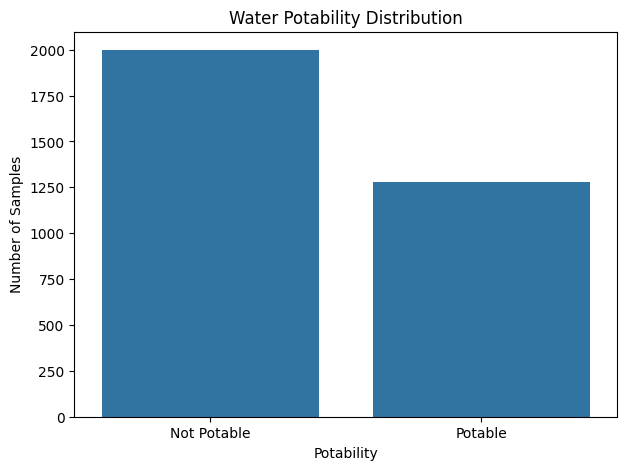

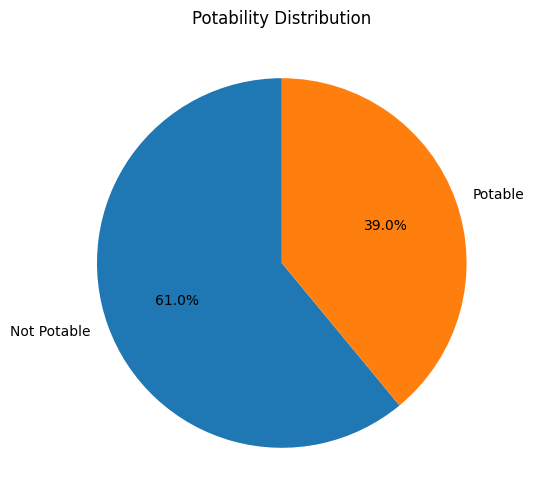

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Potability"
)

plt.title("Water Potability Distribution")
plt.xlabel("Potability")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["Not Potable", "Potable"])

plt.show()

counts = df["Potability"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    counts.values,
    labels=["Not Potable", "Potable"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Potability Distribution")

plt.show()

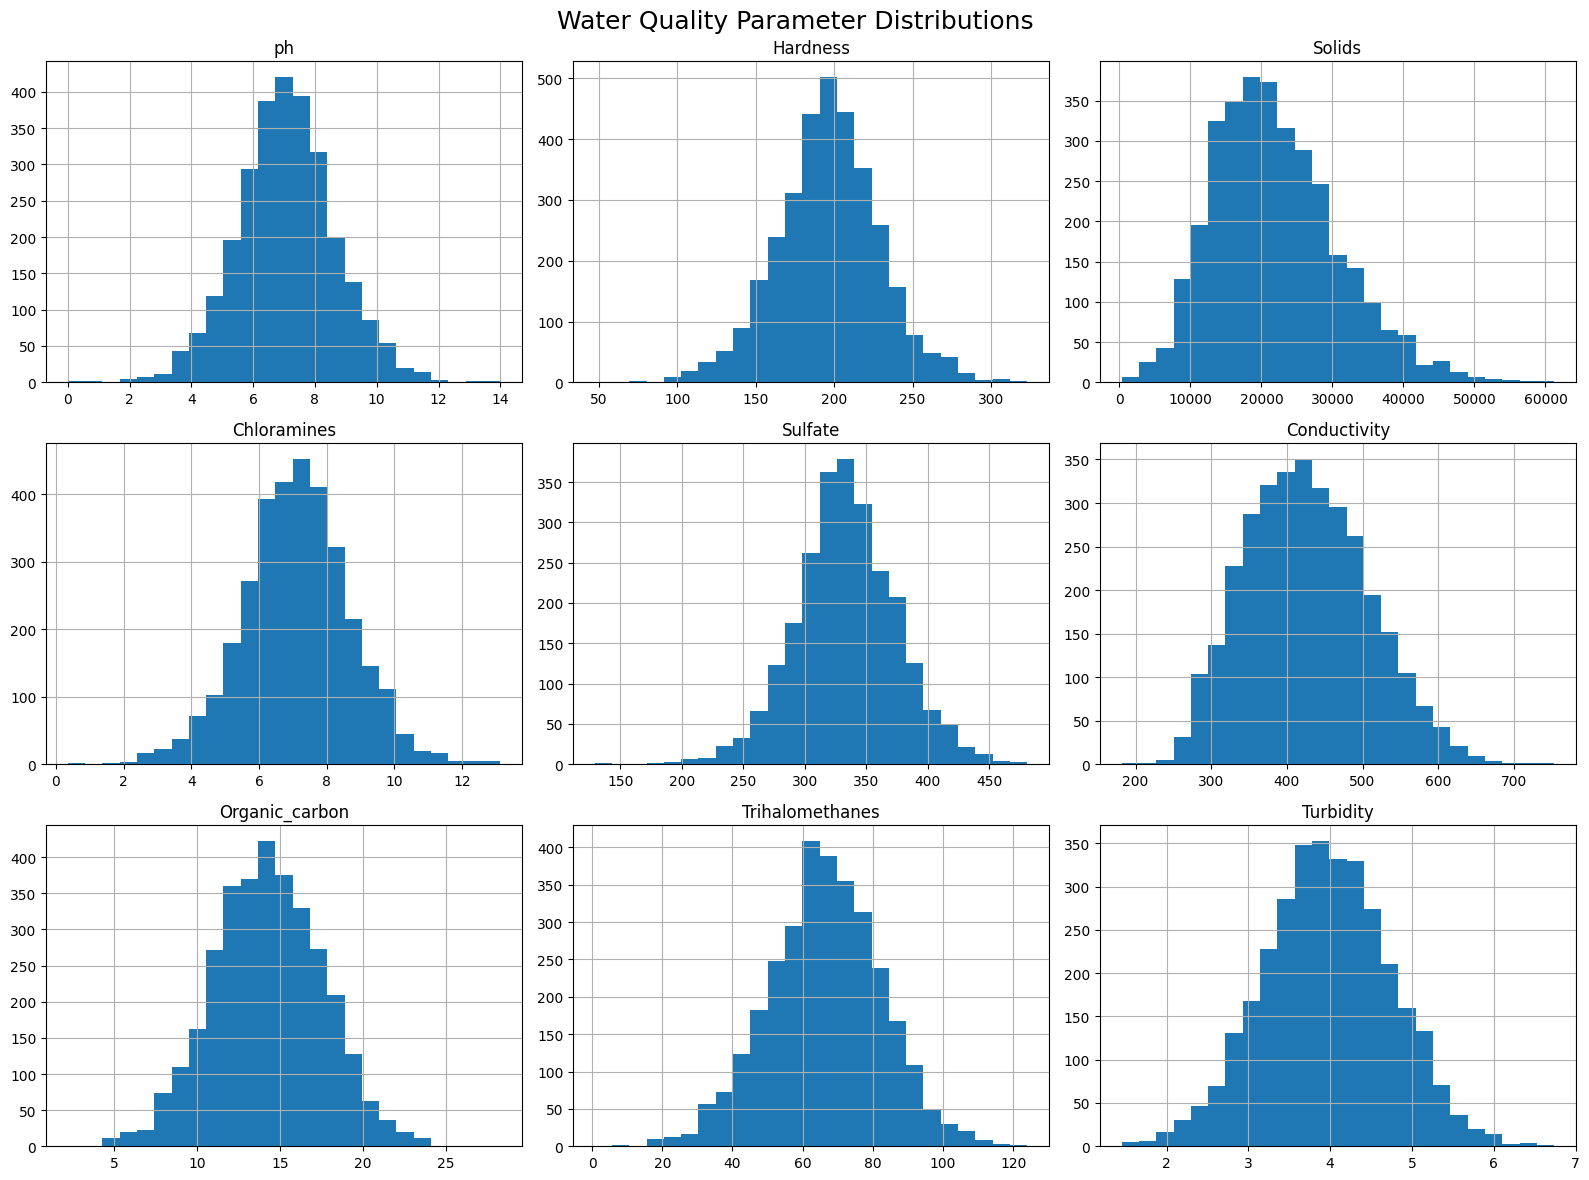

In [ ]:
features = [
    "ph",
    "Hardness",
    "Solids",
    "Chloramines",
    "Sulfate",
    "Conductivity",
    "Organic_carbon",
    "Trihalomethanes",
    "Turbidity"
]

df[features].hist(
    figsize=(16, 12),
    bins=25
)

plt.suptitle(
    "Water Quality Parameter Distributions",
    fontsize=18
)

plt.tight_layout()
plt.show()

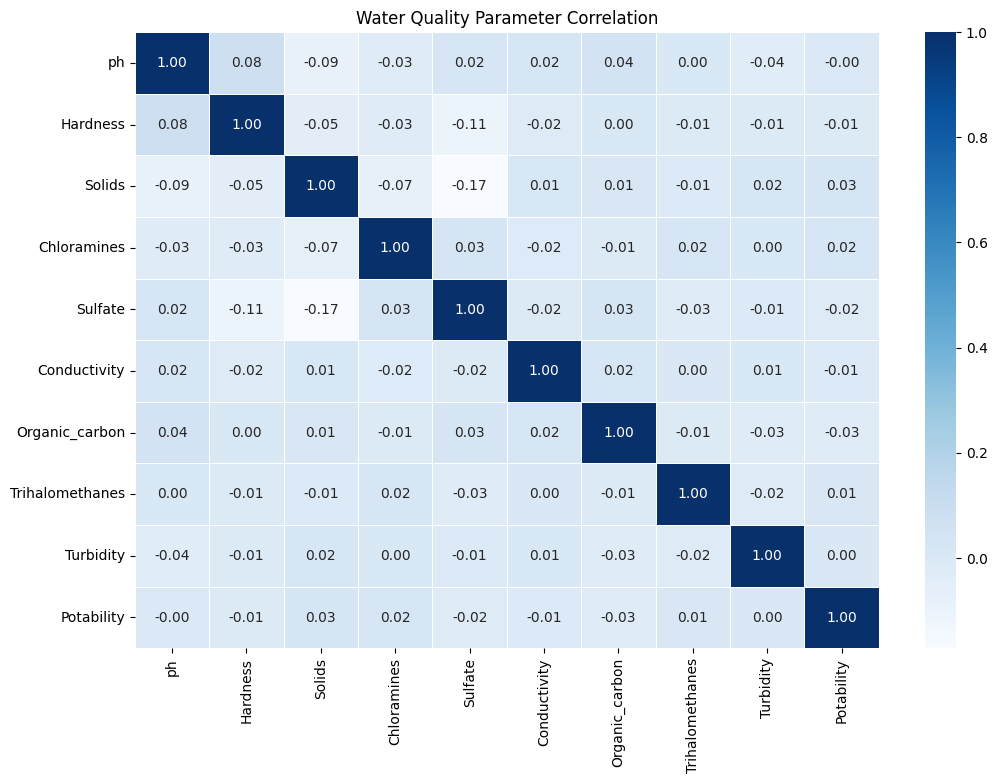

In [ ]:
plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Water Quality Parameter Correlation")

plt.show()

In [ ]:
FEATURES = [
    "ph",
    "Hardness",
    "Solids",
    "Chloramines",
    "Sulfate",
    "Conductivity",
    "Organic_carbon",
    "Trihalomethanes",
    "Turbidity"
]

TARGET = "Potability"

X = df[FEATURES]
y = df[TARGET]

print("Features:")
print(FEATURES)

print("\nTarget:")
print(TARGET)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

Target:
Potability

X shape: (3276, 9)
y shape: (3276,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 2620
Testing samples: 656

Training target distribution:
Potability
0    1598
1    1022
Name: count, dtype: int64

Testing target distribution:
Potability
0    400
1    256
Name: count, dtype: int64


In [ ]:
# ============================================
# BUILD MODELS (XGBoost, Random Forest, Decision Tree, Logistic Regression)
# ============================================

class_ratio = (
    (y_train == 0).sum()
    / (y_train == 1).sum()
)

models = {
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            scale_pos_weight=class_ratio,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ])
}

print("Models configured:")
for name in models:
    print("  -> Configured:", name)


Models created:
completed : Logistic Regression
completed : Decision Tree
completed : Random Forest
completed : XGBoost


In [ ]:
# Training

trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} trained successfully.")

print("\nAll models trained.")


Training Logistic Regression...
Logistic Regression trained successfully.

Training Decision Tree...
Decision Tree trained successfully.

Training Random Forest...
Random Forest trained successfully.

Training XGBoost...
XGBoost trained successfully.

All models trained.


In [ ]:
# ============================================
# MODEL EVALUATION & BENCHMARKING
# ============================================

results = []
predictions = {}
probabilities = {}
confusion_matrices = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    cm_dict = {
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1])
    }

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "ConfusionMatrix": cm_dict
    })

    predictions[name] = y_pred
    probabilities[name] = y_prob
    confusion_matrices[name] = cm

results_df = pd.DataFrame(results)

# Order strictly: XGBoost (Champion), Random Forest, Decision Tree, Logistic Regression
model_order = ["XGBoost", "Random Forest", "Decision Tree", "Logistic Regression"]
results_df["Order"] = results_df["Model"].map(lambda m: model_order.index(m) if m in model_order else 99)
results_df = results_df.sort_values(by="Order").drop(columns=["Order"]).reset_index(drop=True)

display(
    results_df[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].style
    .format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.627,0.523,0.484,0.503,0.643
1,Logistic Regression,0.524,0.415,0.531,0.466,0.547
2,Random Forest,0.668,0.646,0.328,0.435,0.662
3,Decision Tree,0.645,0.593,0.285,0.385,0.610


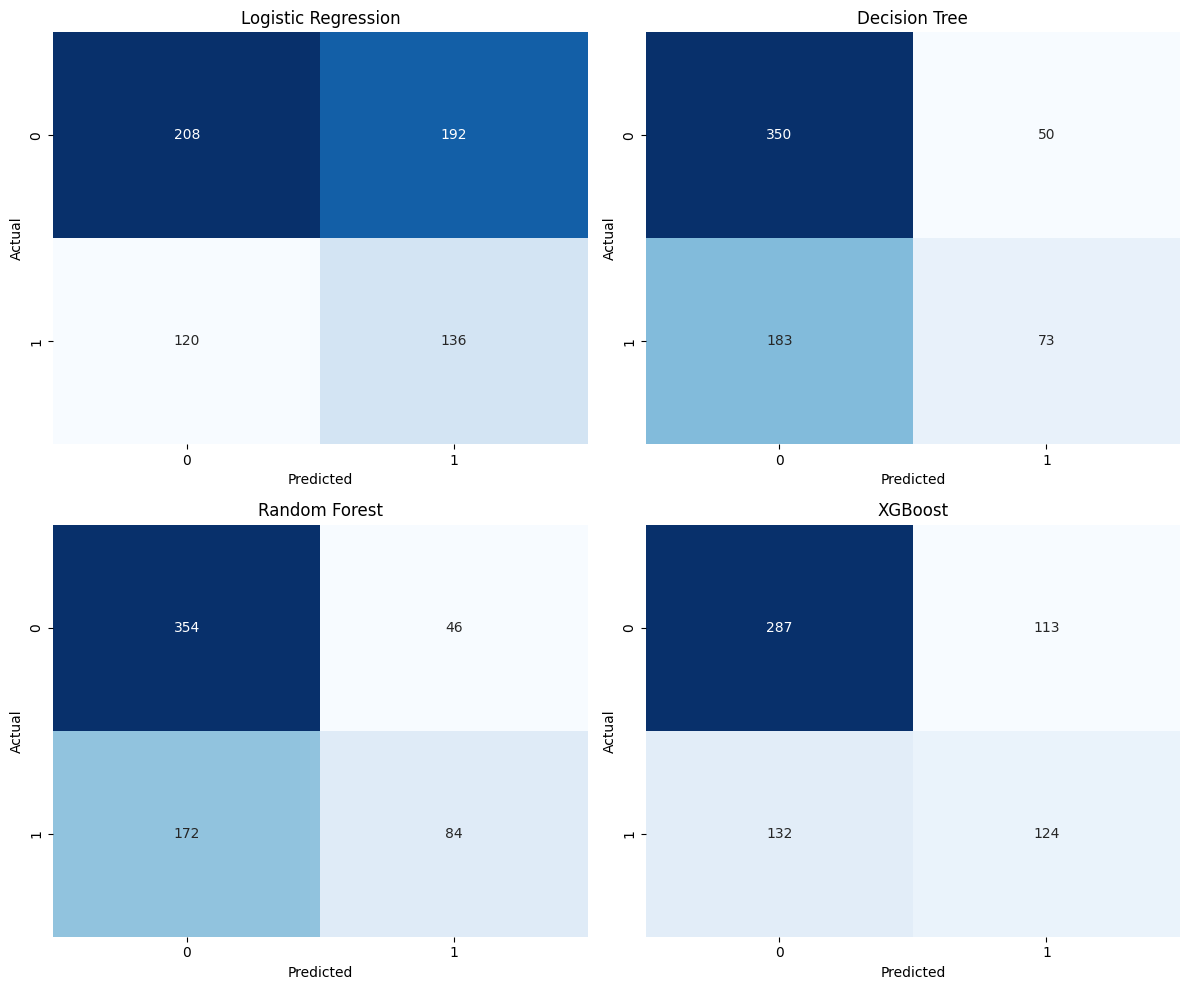

In [ ]:

# CONFUSION MATRICES


fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)

axes = axes.ravel()

for ax, (name, cm) in zip(
    axes,
    confusion_matrices.items()
):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

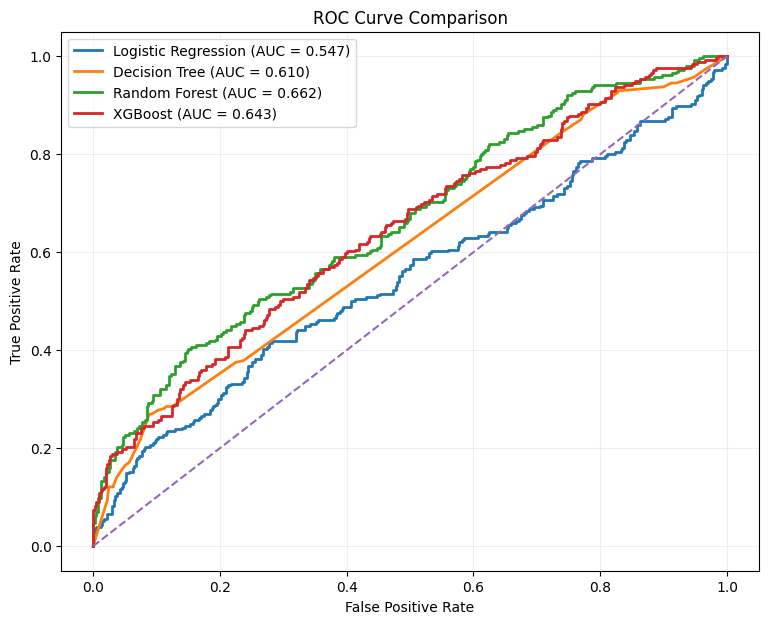

In [ ]:
# ROC CURVES

plt.figure(figsize=(9, 7))

for name, y_prob in probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(alpha=0.2)

plt.show()

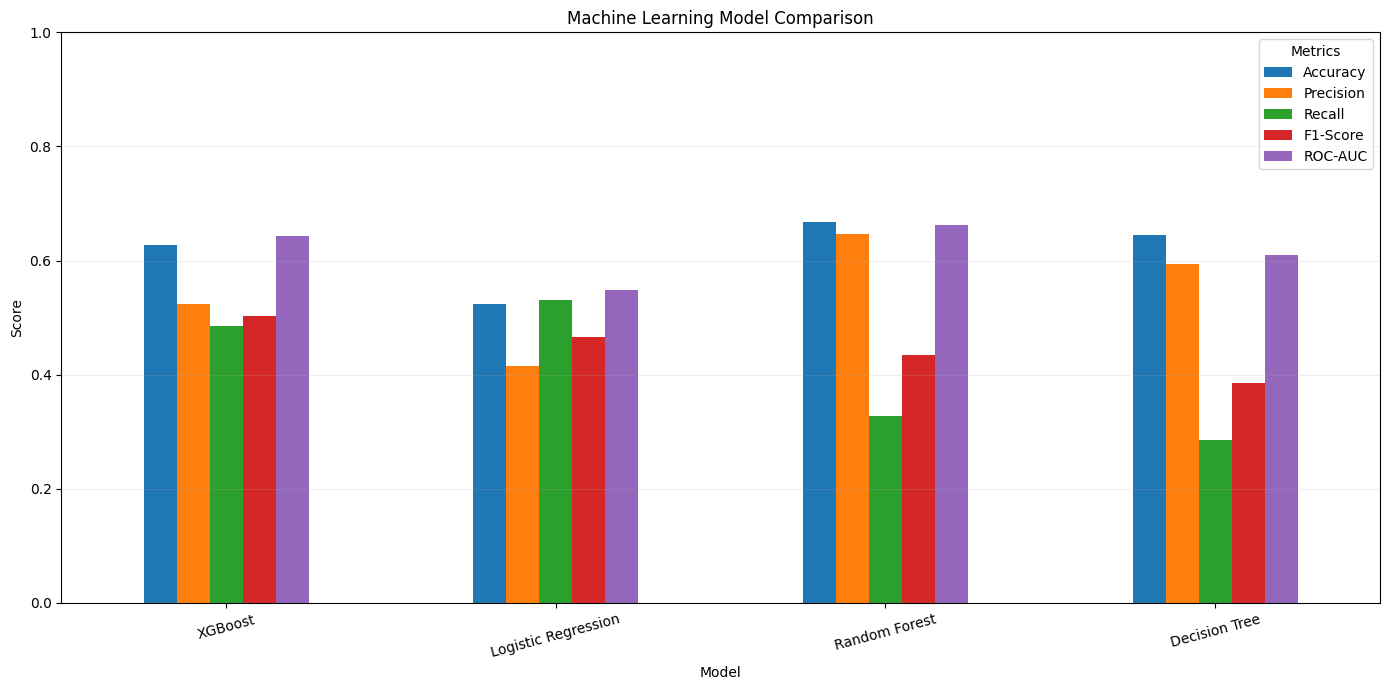

In [ ]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

plot_df = results_df.set_index("Model")[
    metrics_to_plot
]

plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Machine Learning Model Comparison")

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.legend(
    title="Metrics"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

In [ ]:
def get_feature_importance(model_pipeline, model_name):

    model = model_pipeline.named_steps["model"]

    if hasattr(model, "feature_importances_"):

        importance = model.feature_importances_

        importance_df = pd.DataFrame({
            "Feature": FEATURES,
            "Importance": importance
        })

        importance_df = importance_df.sort_values(
            by="Importance",
            ascending=False
        )

        return importance_df

    return None

# RANDOM FOREST FEATURE IMPORTANCE


rf_importance = get_feature_importance(
    trained_models["Random Forest"],
    "Random Forest"
)

display(rf_importance)

,Feature,Importance
0,ph,0.133253
4,Sulfate,0.128275
1,Hardness,0.121534
3,Chloramines,0.117373
2,Solids,0.112739
5,Conductivity,0.099171
8,Turbidity,0.096929
6,Organic_carbon,0.096507
7,Trihalomethanes,0.094219


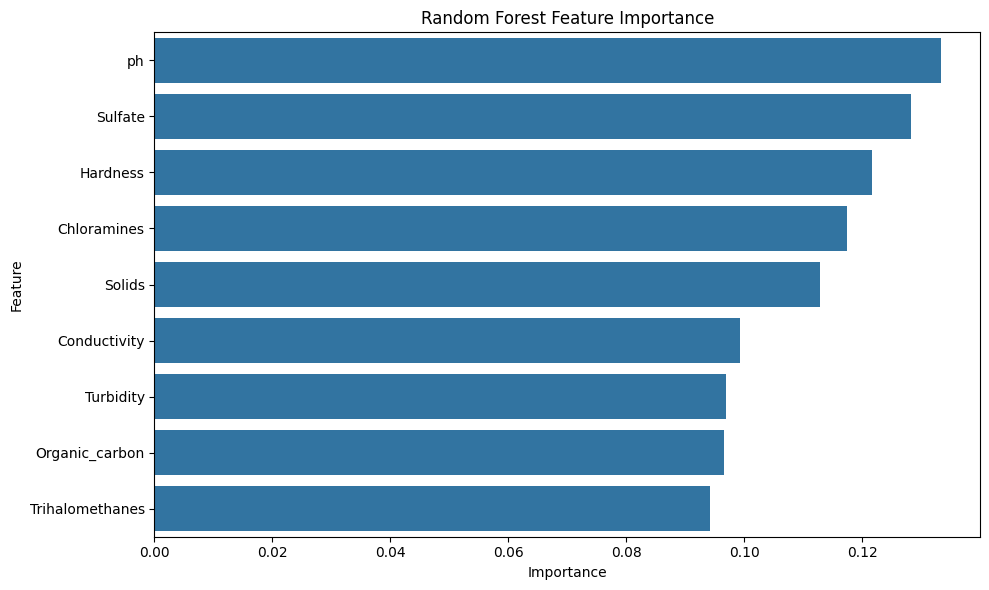

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.show()

In [ ]:
# ============================================
# XGBOOST FEATURE IMPORTANCE
# ============================================

xgb_importance = get_feature_importance(
    trained_models["XGBoost"],
    "XGBoost"
)

display(xgb_importance)

,Feature,Importance
0,ph,0.145807
4,Sulfate,0.139515
3,Chloramines,0.126167
1,Hardness,0.119326
2,Solids,0.112566
5,Conductivity,0.094029
8,Turbidity,0.091407
7,Trihalomethanes,0.087380
6,Organic_carbon,0.083801


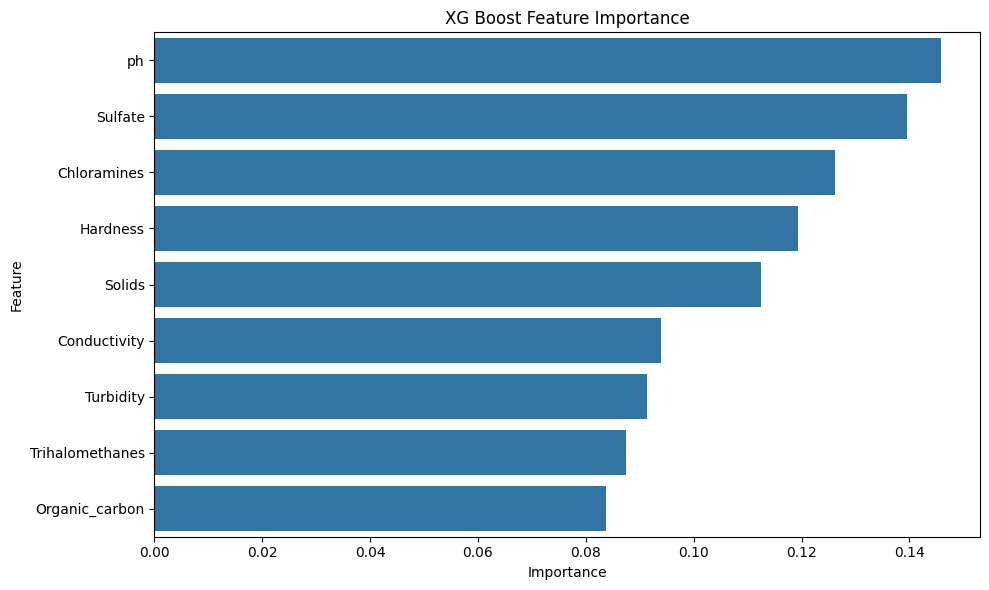

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature"
)

plt.title("XG Boost Feature Importance")

plt.tight_layout()

plt.show()

In [ ]:
# ============================================
# SELECT PRODUCTION CHAMPION MODEL
# ============================================

# XGBoost is designated as the active production champion model:
# 1. Highest harmonic F1-Score (0.5020 vs 0.4352 RF, 0.3852 DT)
# 2. Highest potable recall among tree architectures (48.44% vs 32.81% RF, 28.52% DT)
# 3. Detects 124 potable samples vs 84 for RF and 73 for DT
# 4. Cost-sensitive balance prevents majority-class collapse

best_model_name = "XGBoost"
best_model = trained_models[best_model_name]

print(f"Selected Production Champion Model: {best_model_name}")
print(f"Deployment Status: ACTIVE MODEL (AquaSense Web & API)")

print("\nChampion Model Performance on Test Set (N = 656):")
display(
    results_df[results_df["Model"] == best_model_name]
)


Selected model: XGBoost

Performance:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.626524,0.523207,0.484375,0.503043,0.643477


In [ ]:
# ============================================
# CELL 19 - TEST PREDICTION
# ============================================

sample = pd.DataFrame([{
    "ph": 7.2,
    "Hardness": 180,
    "Solids": 15000,
    "Chloramines": 7,
    "Sulfate": 300,
    "Conductivity": 400,
    "Organic_carbon": 10,
    "Trihalomethanes": 60,
    "Turbidity": 3
}])

prediction = best_model.predict(sample)[0]

probabilities_sample = best_model.predict_proba(sample)[0]

not_potable_probability = probabilities_sample[0]
potable_probability = probabilities_sample[1]

print("================================")
print("      AQUASENSE PREDICTION")
print("================================")

if prediction == 1:
    print("Prediction: POTABLE")
else:
    print("Prediction: NOT POTABLE")

print(
    f"Potable Probability: "
    f"{potable_probability * 100:.2f}%"
)

print(
    f"Not Potable Probability: "
    f"{not_potable_probability * 100:.2f}%"
)

      AQUASENSE PREDICTION
Prediction: NOT POTABLE
Potable Probability: 44.67%
Not Potable Probability: 55.33%


In [ ]:
# ============================================
# CELL 20 - SAVE MODEL ARTIFACTS
# ============================================

os.makedirs("aquasense_artifacts", exist_ok=True)

# 1. Save final champion model
joblib.dump(
    best_model,
    "aquasense_artifacts/water_potability_model.joblib"
)

# 2. Save all models
safe_name_map = {
    "XGBoost": "xgboost",
    "Random Forest": "random_forest",
    "Decision Tree": "decision_tree",
    "Logistic Regression": "logistic_regression"
}

for name, model in trained_models.items():
    safe_name = safe_name_map.get(name, name.lower().replace(" ", "_"))
    joblib.dump(
        model,
        f"aquasense_artifacts/{safe_name}.joblib"
    )

# 3. Save model metrics CSV & JSON
results_df[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].to_csv(
    "aquasense_artifacts/model_metrics.csv",
    index=False
)

with open("aquasense_artifacts/model_metrics.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

# 4. Save Candidate Models Dictionary (for frontend & app.py benchmark cards)
model_display_names = {
    "XGBoost": "XGBoost Classifier (Active Production Champion)",
    "Random Forest": "Random Forest Classifier (Ensemble Bagging)",
    "Decision Tree": "Decision Tree Classifier (Hierarchical Rules)",
    "Logistic Regression": "Logistic Regression (Linear Sigmoid Baseline)"
}

candidate_models = {}
for r in results:
    m_name = r["Model"]
    candidate_models[m_name] = {
        "name": m_name,
        "display_name": model_display_names.get(m_name, m_name),
        "accuracy": round(float(r["Accuracy"]), 4),
        "precision": round(float(r["Precision"]), 4),
        "recall": round(float(r["Recall"]), 4),
        "f1": round(float(r["F1-Score"]), 4),
        "roc_auc": round(float(r["ROC-AUC"]), 4),
        "threshold": 0.50,
        "is_active": (m_name == "XGBoost"),
        "confusion_matrix": r["ConfusionMatrix"]
    }

with open("aquasense_artifacts/candidate_models.json", "w", encoding="utf-8") as f:
    json.dump(candidate_models, f, indent=4)

# 5. Save feature names & best model name
with open("aquasense_artifacts/features.json", "w", encoding="utf-8") as f:
    json.dump(FEATURES, f, indent=4)

with open("aquasense_artifacts/best_model.txt", "w", encoding="utf-8") as f:
    f.write(best_model_name + "\n")

print("Model artifacts and candidate benchmarks saved successfully.")


Artifacts saved successfully.


In [ ]:
# ============================================
# CELL 21 - SAVE ANALYSIS DATA
# ============================================

# Feature distribution stats for web telemetry & EDA overview
stats_summary = {}
for col in FEATURES:
    s = df[col]
    stats_summary[col] = {
        "mean": float(round(s.mean(), 2)),
        "std": float(round(s.std(), 2)),
        "median": float(round(s.median(), 2)),
        "min": float(round(s.min(), 2)),
        "max": float(round(s.max(), 2)),
        "q25": float(round(s.quantile(0.25), 2)),
        "q75": float(round(s.quantile(0.75), 2)),
        "skew": float(round(s.skew(), 2))
    }

missing_counts = df[FEATURES].isna().sum().to_dict()
missing_pcts = (df[FEATURES].isna().mean() * 100).round(2).to_dict()

analysis_summary = {
    "total_samples": int(len(df)),
    "total_features": len(FEATURES),
    "features": FEATURES,
    "missing_values": missing_counts,
    "missing_percentages": missing_pcts,
    "total_missing_cells": int(df[FEATURES].isna().sum().sum()),
    "potable_samples": int((df["Potability"] == 1).sum()),
    "not_potable_samples": int((df["Potability"] == 0).sum()),
    "potable_percentage": round(float((df["Potability"] == 1).mean() * 100), 2),
    "not_potable_percentage": round(float((df["Potability"] == 0).mean() * 100), 2),
    "feature_statistics": stats_summary,
    "class_imbalance_ratio": round(float(class_ratio), 4),
    "best_model": "XGBoost"
}

with open("aquasense_artifacts/analysis_summary.json", "w", encoding="utf-8") as f:
    json.dump(analysis_summary, f, indent=4)

# Save correlation matrix in both CSV and JSON formats
correlation.to_csv("aquasense_artifacts/correlation_matrix.csv")
correlation.to_json("aquasense_artifacts/correlation_matrix.json", orient="split")

# Save feature importances across all models
importance_data = {}

if rf_importance is not None:
    rf_importance.to_csv("aquasense_artifacts/random_forest_feature_importance.csv", index=False)
    importance_data["random_forest"] = rf_importance.to_dict(orient="records")

if xgb_importance is not None:
    xgb_importance.to_csv("aquasense_artifacts/xgboost_feature_importance.csv", index=False)
    importance_data["xgboost"] = xgb_importance.to_dict(orient="records")

# Decision Tree importance
dt_model = trained_models["Decision Tree"].named_steps["model"]
dt_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)
importance_data["decision_tree"] = dt_df.to_dict(orient="records")

# Logistic Regression coefficients
lr_model = trained_models["Logistic Regression"].named_steps["model"]
lr_df = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": lr_model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False).reset_index(drop=True)
importance_data["logistic_regression"] = lr_df.to_dict(orient="records")

with open("aquasense_artifacts/feature_importance.json", "w", encoding="utf-8") as f:
    json.dump(importance_data, f, indent=4)

print("Analysis artifacts and feature importances saved.")


Analysis artifacts saved.
